In [ ]:
# Process Efficiency Dashboard - IT Support Operations
### Simulating Enterprise Claims/Ops KPI Analysis (ITSM Workflow)

**Author:** Saran Chandrasekharan Unnithan Rani  
**Dataset:** Synthetic IT Support Tickets (100,000 records) — [Kaggle](https://www.kaggle.com/datasets/ahsanneural/synthetic-it-support-tickets)  
**Tools:** Python (pandas, matplotlib, seaborn, scipy) → Power BI  

---

### Business Context
This project mirrors the KPI reporting and process improvement work conducted at **HP Inc.**, where I supported claims management operations across EMEA and Asia-Pacific business units. The analysis simulates:
- SLA breach detection by priority and region
- Turnaround time trend analysis
- Root cause drill-down of operational bottlenecks
- KPI summary export for stakeholder dashboards

---

## 0. Environment Setup

In [5]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')

# Plot styling — clean, professional
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 150,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9
})

PROCESSED_PATH = '../data/processed/'
VISUALS_PATH   = '../visuals/'
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(VISUALS_PATH, exist_ok=True)

print('Environment ready')

Environment ready


---
## 1. Data Ingestion

In [7]:
path = kagglehub.dataset_download('ahsanneural/synthetic-it-support-tickets')
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]
df_raw = pd.read_csv(os.path.join(path, csv_file))

print(f'Loaded: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
df_raw.head(3)

Loaded: 100,000 rows × 20 columns


,ticket_id,created_at,customer_id,customer_segment,channel,product_area,issue_type,priority,status,sla_plan,initial_message,agent_first_reply,resolution_summary,resolution_time_hours,reopened,customer_sentiment,csat_score,has_attachment,platform,region
0,TCKT_000001,2024-01-31T05:14:27,CUST_00861,individual,email,data_export,account_access,low,resolved,standard,I cannot log in; the system says my password i...,Sorry to hear you're having trouble accessing ...,Reset account credentials and confirmed succes...,36.53,0,very_negative,1,0,android,EU
1,TCKT_000002,2024-10-20T06:15:49,CUST_00770,individual,in_app,billing,security_concern,medium,closed_no_action,standard,I noticed a suspicious login on my account.,We take security very seriously. Our team is r...,Ticket closed without further action after no ...,238.32,0,neutral,3,0,web,NaN
2,TCKT_000003,2024-06-18T21:35:54,CUST_02559,small_business,chat,api_integration,bug,low,in_progress,standard,The api integration feature is not saving my c...,Thanks for reporting this bug. We will look in...,NaN,NaN,0,neutral,3,0,android,MEA


In [ ]:
---
## 2. Data Cleaning & Quality Assessment

In [8]:
df = df_raw.copy()

# ----- 2.1 Parse datetime -----
df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')

# ----- 2.2 Null analysis -----
null_summary = pd.DataFrame({
    'null_count' : df.isnull().sum(),
    'null_pct'   : (df.isnull().sum() / len(df) * 100).round(2)
}).query('null_count > 0').sort_values('null_pct', ascending=False)

print('=== Columns with Nulls ===')
print(null_summary)

# ----- 2.3 Handle nulls -----
# Region: fill with 'Unknown' — common ops handling for missing geo-tags
df['region'] = df['region'].fillna('Unknown')

# resolution_time_hours: NaN = ticket not yet resolved (in_progress / open)
# Keep as-is for resolved tickets; flag unresolved separately
df['is_resolved'] = df['status'].isin(['resolved'])
df_resolved = df[df['is_resolved']].copy()

print(f'\nResolved tickets: {len(df_resolved):,} ({len(df_resolved)/len(df)*100:.1f}%)')
print(f'   Open/In-progress : {len(df) - len(df_resolved):,}')

=== Columns with Nulls ===
                       null_count  null_pct
resolution_summary          39887     39.89
resolution_time_hours       39887     39.89
region                      19997     20.00

Resolved tickets: 50,131 (50.1%)
   Open/In-progress : 49,869


---
## 3. Feature Engineering — SLA Breach Detection

> **Business Rule:** SLA thresholds defined per priority tier — mirroring industry-standard ITSM contracts (P1=critical, P4=low). This is the same logic used in enterprise claims management to flag breached service commitments.

In [9]:
# ----- 3.1 SLA threshold map (hours) — standard enterprise ITSM -----
SLA_MAP = {
    'critical' : 4,
    'high'     : 8,
    'medium'   : 24,
    'low'      : 72
}

df['sla_threshold_hrs'] = df['priority'].str.lower().map(SLA_MAP)
df['sla_breached']      = (
    df['resolution_time_hours'].notna() &
    (df['resolution_time_hours'] > df['sla_threshold_hrs'])
).astype(int)

# ----- 3.2 Time-based features -----
df['year_month']  = df['created_at'].dt.to_period('M')
df['day_of_week'] = df['created_at'].dt.day_name()
df['hour_of_day'] = df['created_at'].dt.hour

# ----- 3.3 Resolution speed bucket -----
def resolution_bucket(hours):
    if pd.isna(hours):    return 'Unresolved'
    elif hours <= 4:      return '0–4 hrs'
    elif hours <= 24:     return '4–24 hrs'
    elif hours <= 72:     return '1–3 days'
    else:                 return '3+ days'

df['resolution_bucket'] = df['resolution_time_hours'].apply(resolution_bucket)

print('Features engineered')
print(f"   SLA breach rate (overall): {df['sla_breached'].mean()*100:.1f}%")
df[['priority','sla_threshold_hrs','resolution_time_hours','sla_breached']].head()

Features engineered
   SLA breach rate (overall): 24.9%


,priority,sla_threshold_hrs,resolution_time_hours,sla_breached
0,low,72.0,36.53,0
1,medium,24.0,238.32,1
2,low,72.0,NaN,0
3,medium,24.0,NaN,0
4,low,72.0,61.32,0


---
## 4. KPI Summary Table

> This is the core deliverable — a stakeholder-ready KPI table by region, equivalent to what was published to 200+ stakeholders at HP Inc.

In [10]:
kpi_by_region = df.groupby('region').agg(
    total_tickets        = ('ticket_id',            'count'),
    resolved_tickets     = ('is_resolved',           'sum'),
    avg_resolution_hrs   = ('resolution_time_hours', 'mean'),
    median_resolution_hrs= ('resolution_time_hours', 'median'),
    sla_breach_count     = ('sla_breached',          'sum'),
    sla_breach_rate_pct  = ('sla_breached',          lambda x: round(x.mean()*100, 2)),
    reopen_rate_pct      = ('reopened',              lambda x: round(x.mean()*100, 2)),
    avg_csat             = ('csat_score',            'mean')
).round(2).reset_index()

kpi_by_region['resolution_rate_pct'] = (
    kpi_by_region['resolved_tickets'] / kpi_by_region['total_tickets'] * 100
).round(2)

kpi_by_region = kpi_by_region.sort_values('sla_breach_rate_pct', ascending=False)

print('=== KPI Summary by Region ===')
kpi_by_region

=== KPI Summary by Region ===


,region,total_tickets,resolved_tickets,avg_resolution_hrs,median_resolution_hrs,sla_breach_count,sla_breach_rate_pct,reopen_rate_pct,avg_csat,resolution_rate_pct
0,APAC,19933,10071,45.87,30.48,5179,25.98,4.99,2.23,50.52
3,MEA,20151,10089,45.36,30.53,5064,25.13,5.14,2.23,50.07
2,LATAM,19959,9880,45.31,29.46,4926,24.68,5.22,2.24,49.50
1,EU,19960,10064,44.16,29.49,4915,24.62,5.09,2.25,50.42
4,Unknown,19997,10027,44.36,29.85,4865,24.33,4.79,2.25,50.14


In [11]:
# KPI by Priority
kpi_by_priority = df.groupby('priority').agg(
    total_tickets        = ('ticket_id',            'count'),
    avg_resolution_hrs   = ('resolution_time_hours', 'mean'),
    sla_breach_rate_pct  = ('sla_breached',          lambda x: round(x.mean()*100, 2)),
    avg_csat             = ('csat_score',            'mean')
).round(2).reset_index()

print('=== KPI Summary by Priority ===')
kpi_by_priority

=== KPI Summary by Priority ===


,priority,total_tickets,avg_resolution_hrs,sla_breach_rate_pct,avg_csat
0,high,19865,31.56,44.07,2.25
1,low,39735,55.61,7.85,2.24
2,medium,35313,43.28,37.03,2.24
3,urgent,5087,26.71,0.00,2.24


---
## 5. Analysis & Visualizations

### 5.1 SLA Breach Rate by Region

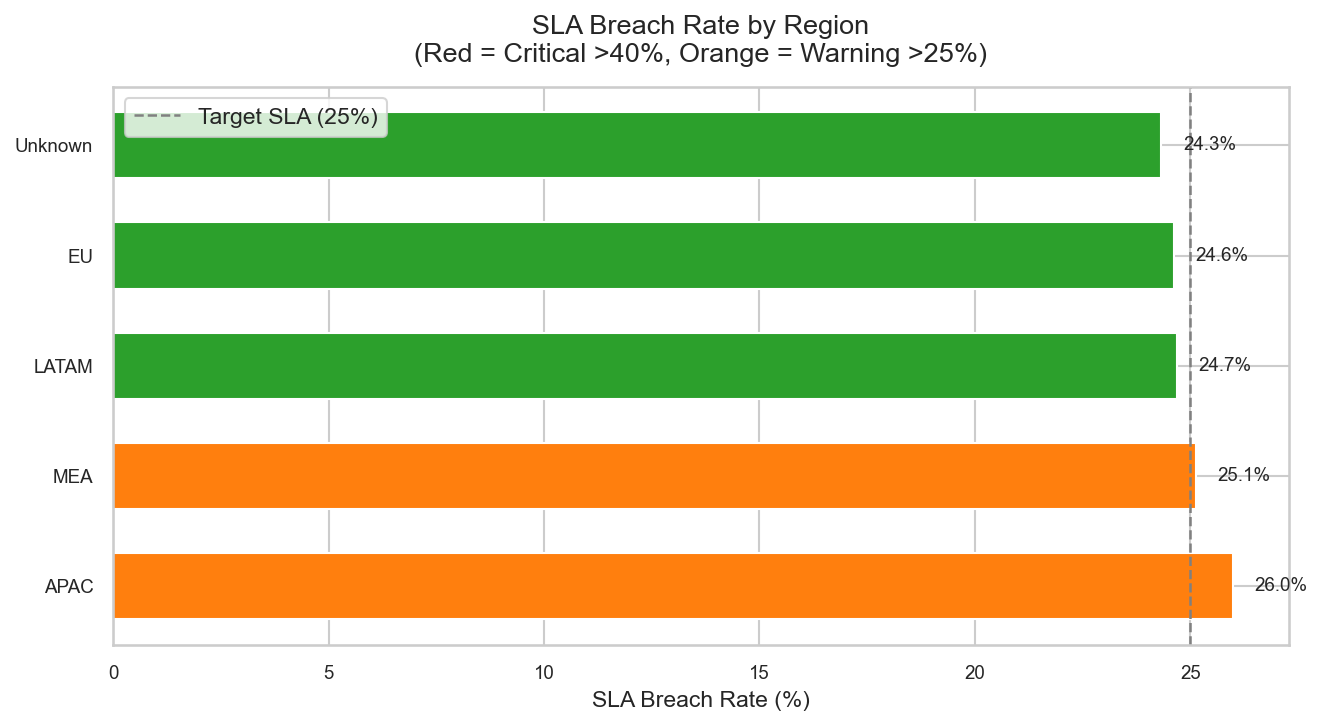

Saved: 01_sla_breach_by_region.png


In [12]:
fig, ax = plt.subplots(figsize=(9, 5))

colors = ['#d62728' if r > 40 else '#ff7f0e' if r > 25 else '#2ca02c'
          for r in kpi_by_region['sla_breach_rate_pct']]

bars = ax.barh(kpi_by_region['region'], kpi_by_region['sla_breach_rate_pct'],
               color=colors, edgecolor='white', height=0.6)

ax.axvline(x=25, color='gray', linestyle='--', linewidth=1.2, label='Target SLA (25%)')

for bar, val in zip(bars, kpi_by_region['sla_breach_rate_pct']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)

ax.set_xlabel('SLA Breach Rate (%)')
ax.set_title('SLA Breach Rate by Region\n(Red = Critical >40%, Orange = Warning >25%)', pad=12)
ax.legend()
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}01_sla_breach_by_region.png', bbox_inches='tight')
plt.show()
print('Saved: 01_sla_breach_by_region.png')

### 5.2 Monthly SLA Breach Trend

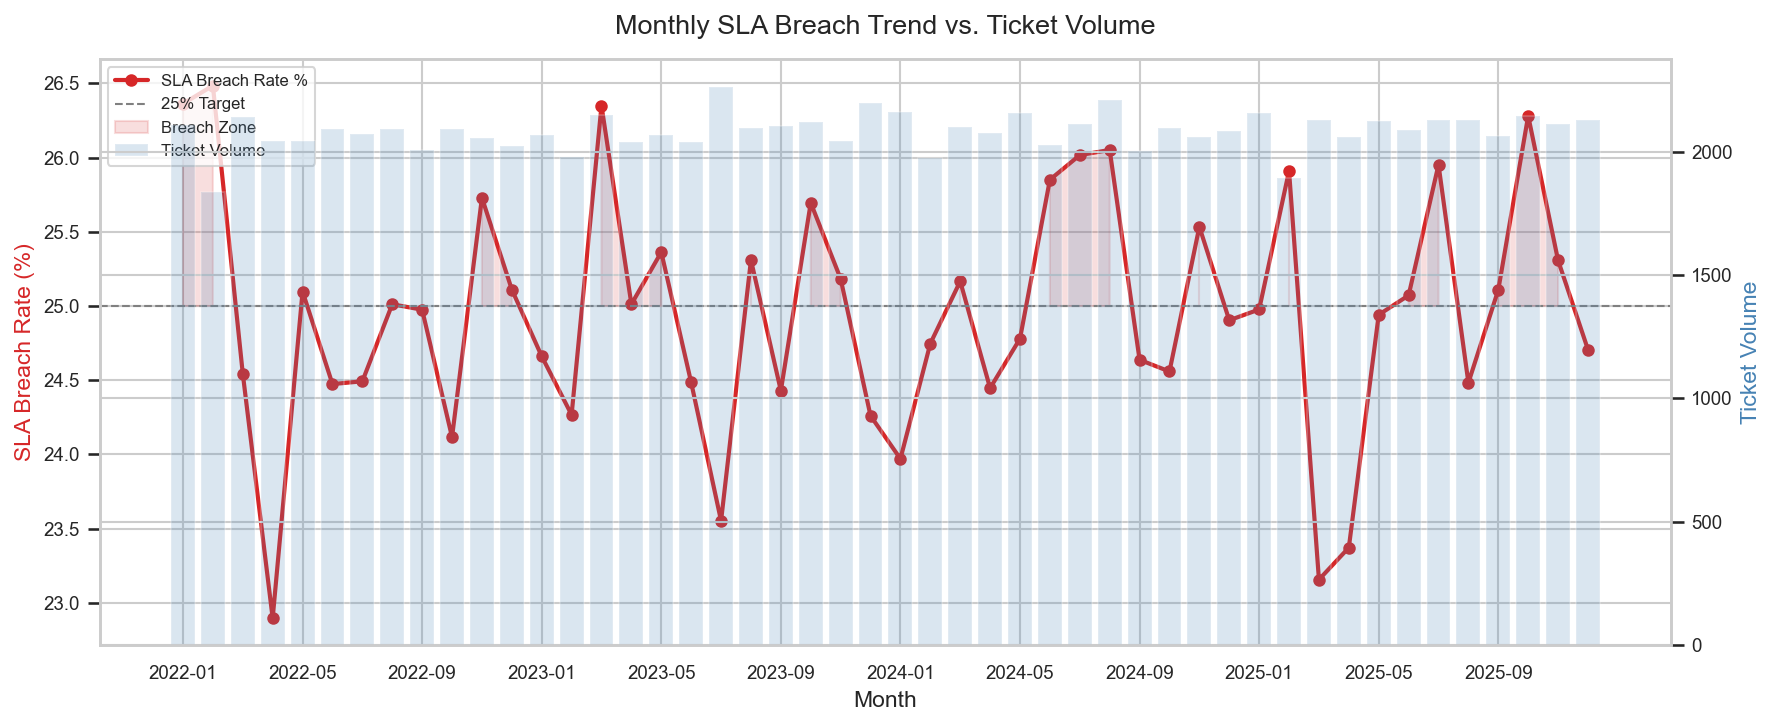

Saved: 02_monthly_sla_trend.png


In [13]:
monthly_trend = df.groupby('year_month').agg(
    breach_rate = ('sla_breached', 'mean'),
    ticket_vol  = ('ticket_id',   'count')
).reset_index()
monthly_trend['year_month_str'] = monthly_trend['year_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(monthly_trend['year_month_str'], monthly_trend['breach_rate']*100,
         color='#d62728', marker='o', linewidth=2, markersize=5, label='SLA Breach Rate %')
ax1.axhline(y=25, color='gray', linestyle='--', linewidth=1, label='25% Target')
ax1.fill_between(monthly_trend['year_month_str'], monthly_trend['breach_rate']*100,
                 25, where=monthly_trend['breach_rate']*100 > 25,
                 alpha=0.15, color='#d62728', label='Breach Zone')

ax2.bar(monthly_trend['year_month_str'], monthly_trend['ticket_vol'],
        alpha=0.2, color='steelblue', label='Ticket Volume')

ax1.set_ylabel('SLA Breach Rate (%)', color='#d62728')
ax2.set_ylabel('Ticket Volume', color='steelblue')
ax1.set_xlabel('Month')
ax1.set_title('Monthly SLA Breach Trend vs. Ticket Volume', pad=12)

tick_positions = range(0, len(monthly_trend), max(1, len(monthly_trend)//10))
ax1.set_xticks([monthly_trend['year_month_str'].iloc[i] for i in tick_positions])
plt.xticks(rotation=45)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}02_monthly_sla_trend.png', bbox_inches='tight')
plt.show()
print('Saved: 02_monthly_sla_trend.png')

### 5.3 Root Cause Drill-Down — Breach by Region × Issue Type

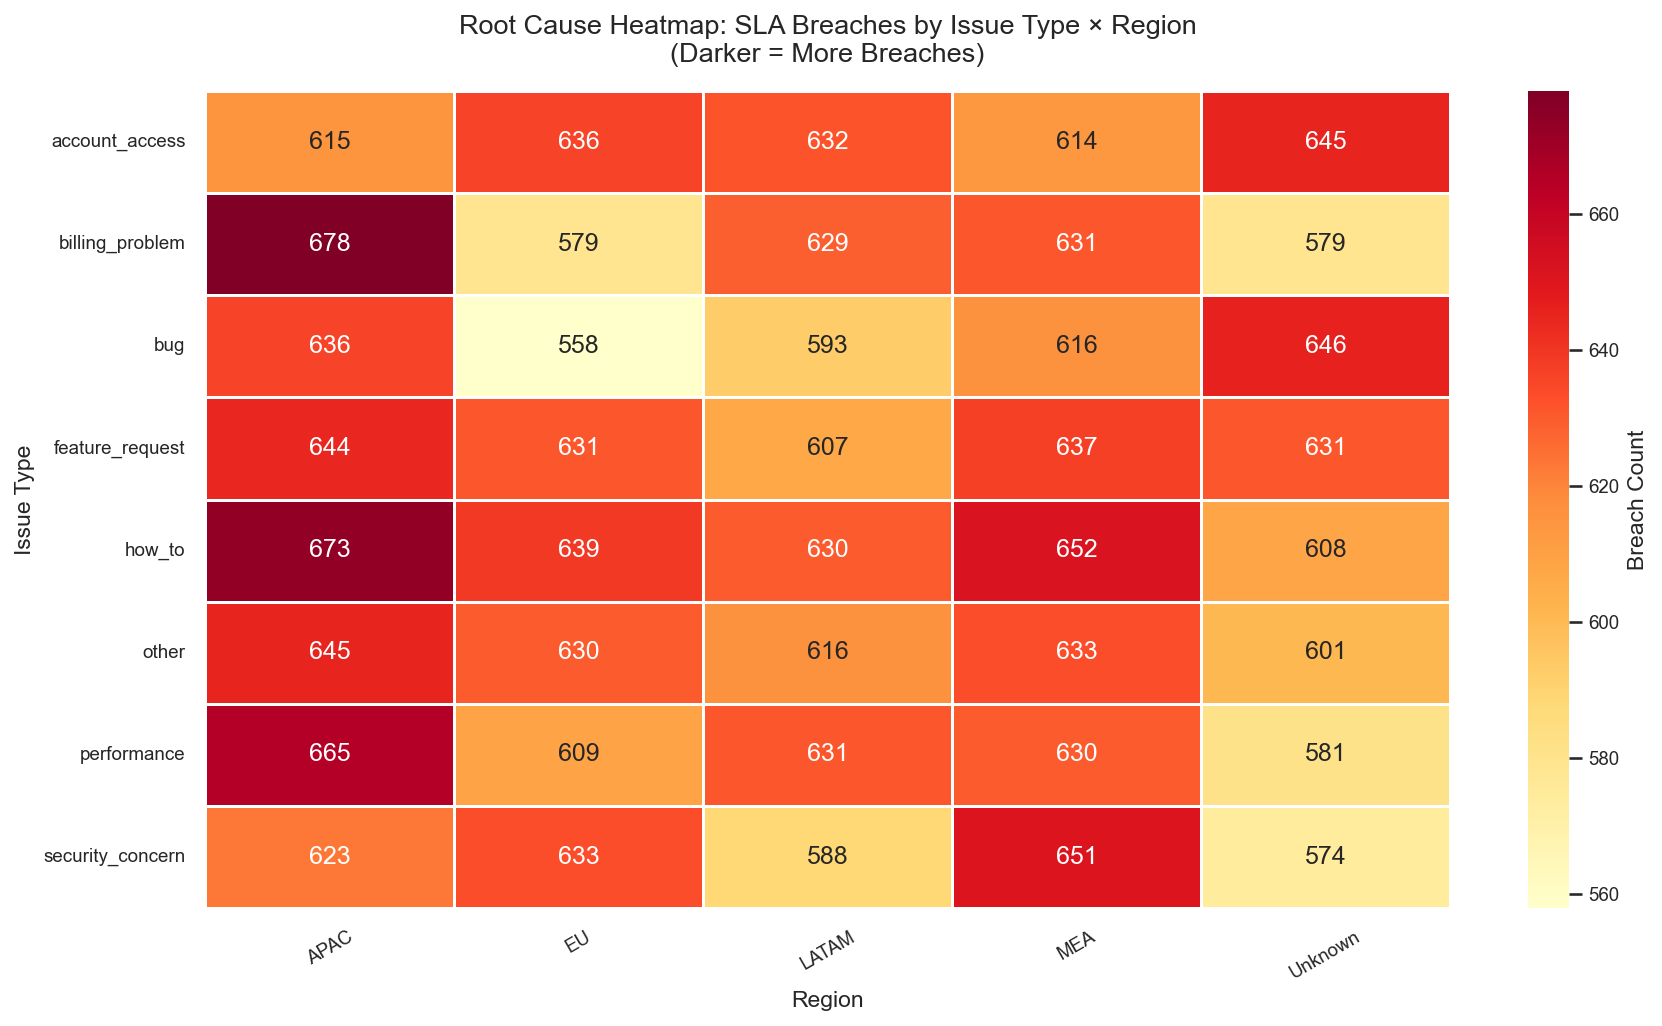

Saved: 03_root_cause_heatmap.png


In [14]:
root_cause = df[df['sla_breached'] == 1].groupby(
    ['region', 'issue_type']
).size().reset_index(name='breach_count')

pivot = root_cause.pivot(index='issue_type', columns='region', values='breach_count').fillna(0)

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': 'Breach Count'})

ax.set_title('Root Cause Heatmap: SLA Breaches by Issue Type × Region\n(Darker = More Breaches)', pad=14)
ax.set_xlabel('Region')
ax.set_ylabel('Issue Type')
plt.xticks(rotation=30)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}03_root_cause_heatmap.png', bbox_inches='tight')
plt.show()
print('Saved: 03_root_cause_heatmap.png')

### 5.4 Resolution Time Distribution by Priority

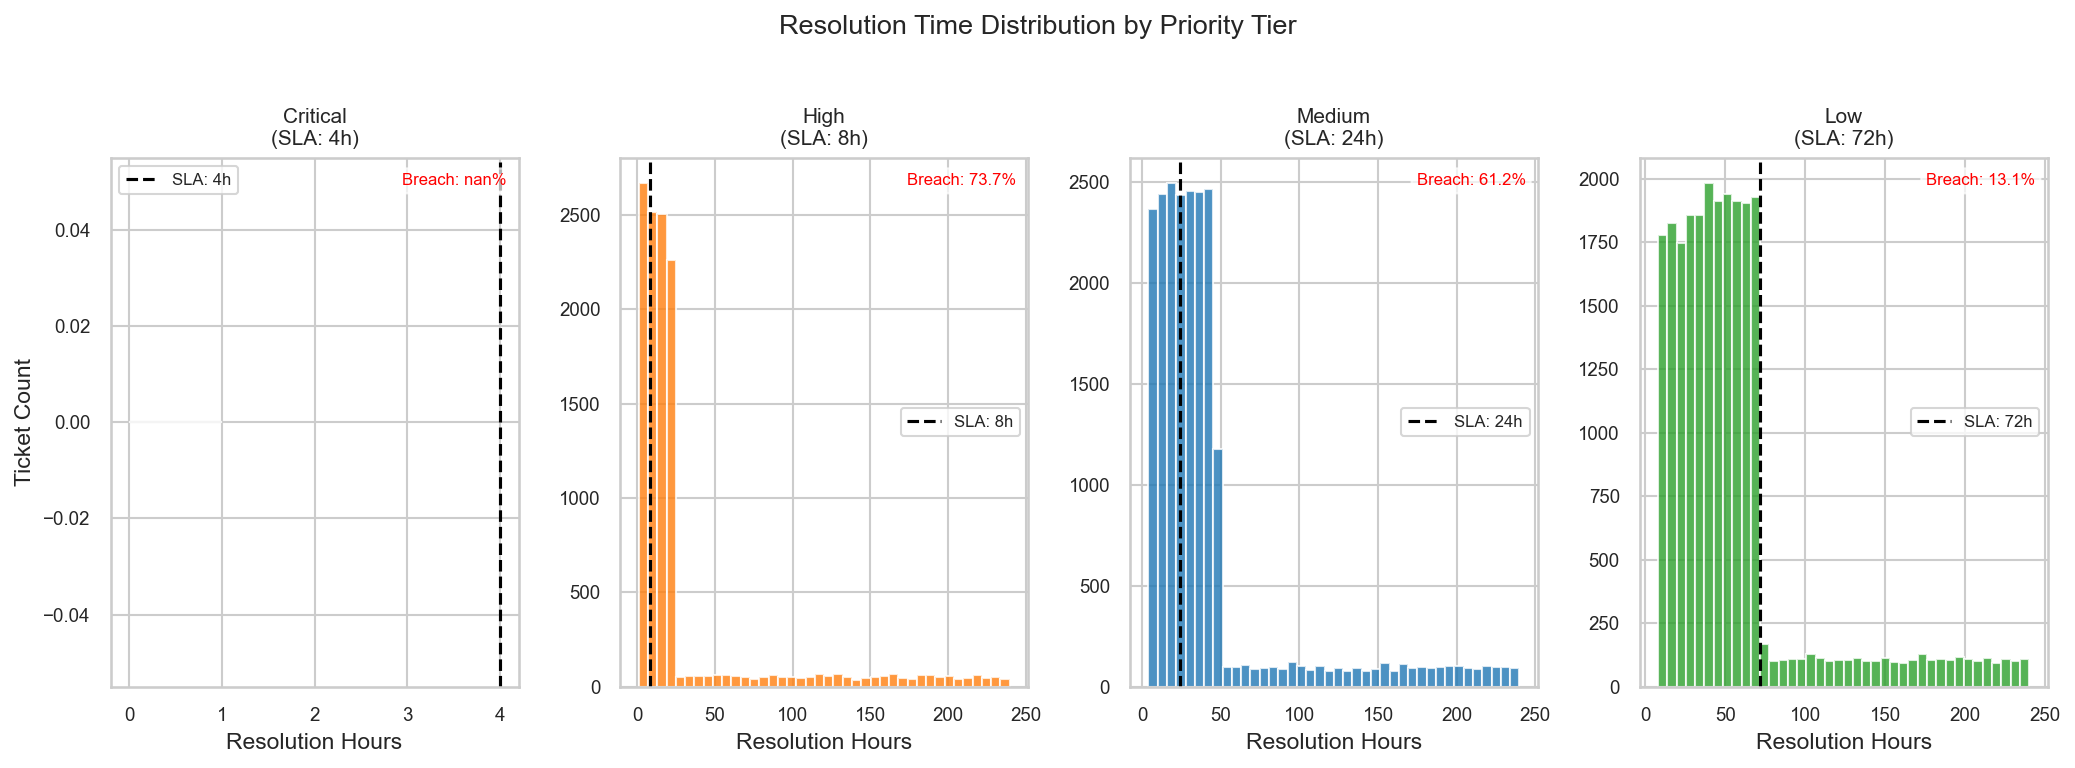

Saved: 04_resolution_dist_by_priority.png


In [15]:
df_res = df[df['resolution_time_hours'].notna() & (df['resolution_time_hours'] < 300)]
priority_order = ['critical', 'high', 'medium', 'low']

fig, axes = plt.subplots(1, 4, figsize=(14, 5), sharey=False)
palette = {'critical': '#d62728', 'high': '#ff7f0e', 'medium': '#1f77b4', 'low': '#2ca02c'}

for ax, p in zip(axes, priority_order):
    data = df_res[df_res['priority'] == p]['resolution_time_hours']
    sla  = SLA_MAP[p]
    ax.hist(data, bins=40, color=palette[p], alpha=0.8, edgecolor='white')
    ax.axvline(sla, color='black', linestyle='--', linewidth=1.5, label=f'SLA: {sla}h')
    ax.set_title(f'{p.capitalize()}\n(SLA: {sla}h)', fontsize=10)
    ax.set_xlabel('Resolution Hours')
    ax.legend(fontsize=8)
    breach_pct = (data > sla).mean() * 100
    ax.text(0.97, 0.97, f'Breach: {breach_pct:.1f}%',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=8, color='red',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

axes[0].set_ylabel('Ticket Count')
fig.suptitle('Resolution Time Distribution by Priority Tier', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}04_resolution_dist_by_priority.png', bbox_inches='tight')
plt.show()
print('Saved: 04_resolution_dist_by_priority.png')

### 5.5 CSAT Score vs. SLA Compliance

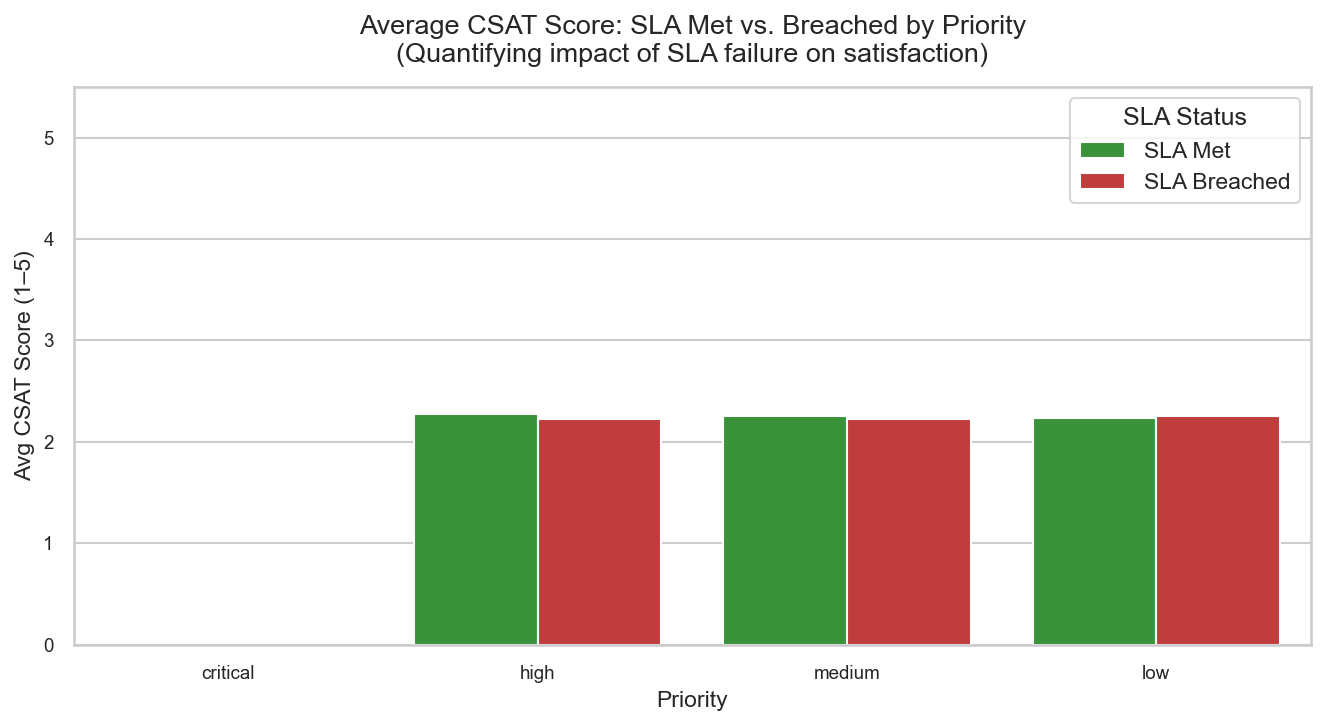

Saved: 05_csat_vs_sla.png


In [16]:
csat_sla = df.groupby(['sla_breached', 'priority']).agg(
    avg_csat = ('csat_score', 'mean'),
    count    = ('ticket_id',  'count')
).reset_index()
csat_sla['sla_status'] = csat_sla['sla_breached'].map({0: 'SLA Met', 1: 'SLA Breached'})

fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=csat_sla, x='priority', y='avg_csat', hue='sla_status',
            palette={'SLA Met': '#2ca02c', 'SLA Breached': '#d62728'},
            order=priority_order, ax=ax)

ax.set_title('Average CSAT Score: SLA Met vs. Breached by Priority\n(Quantifying impact of SLA failure on satisfaction)', pad=12)
ax.set_xlabel('Priority')
ax.set_ylabel('Avg CSAT Score (1–5)')
ax.set_ylim(0, 5.5)
ax.legend(title='SLA Status')
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}05_csat_vs_sla.png', bbox_inches='tight')
plt.show()
print('Saved: 05_csat_vs_sla.png')

### 5.6 Ticket Volume by Channel & Customer Segment

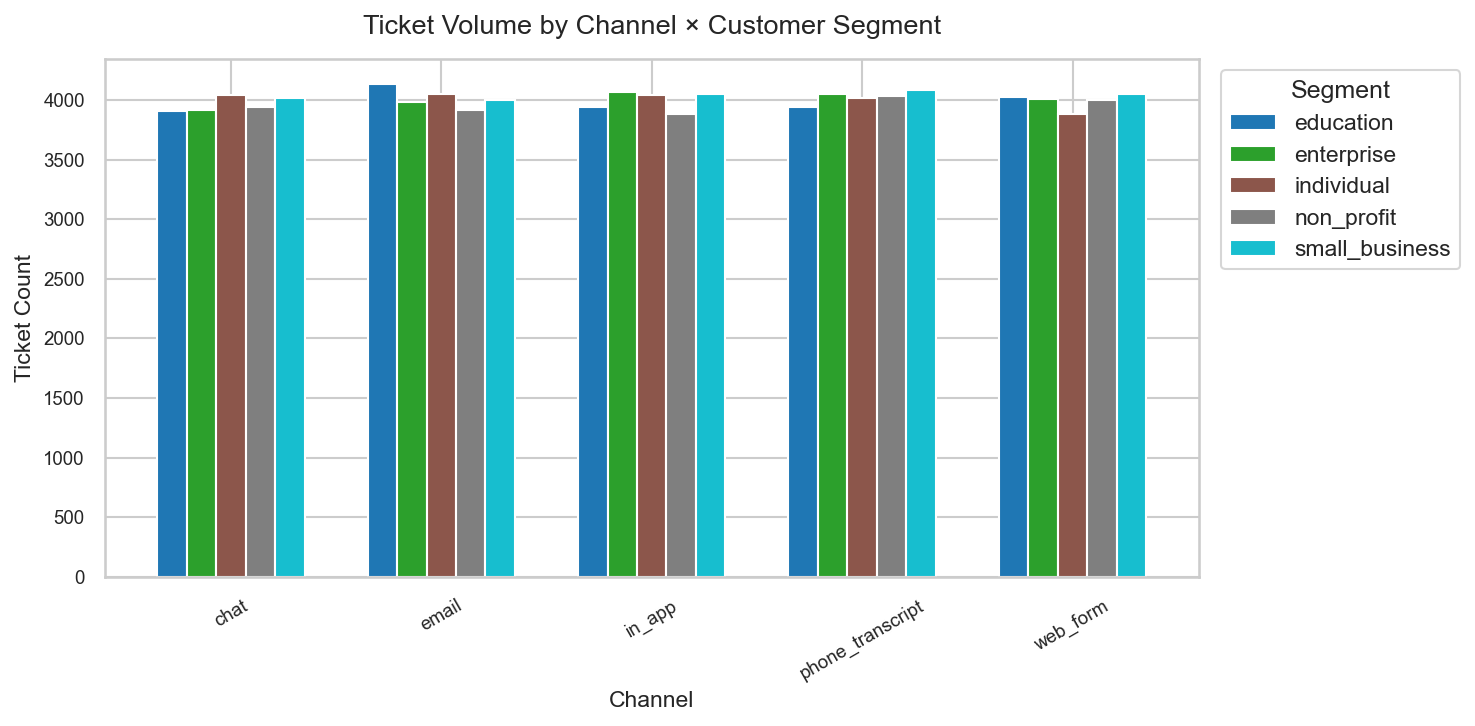

Saved: 06_volume_channel_segment.png


In [17]:
channel_seg = df.groupby(['channel', 'customer_segment']).size().reset_index(name='count')
pivot_cs = channel_seg.pivot(index='channel', columns='customer_segment', values='count').fillna(0)

pivot_cs.plot(kind='bar', figsize=(10, 5), colormap='tab10', edgecolor='white', width=0.7)
plt.title('Ticket Volume by Channel × Customer Segment', pad=12)
plt.xlabel('Channel')
plt.ylabel('Ticket Count')
plt.xticks(rotation=30)
plt.legend(title='Segment', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}06_volume_channel_segment.png', bbox_inches='tight')
plt.show()
print('Saved: 06_volume_channel_segment.png')

---
## 6. Statistical Validation

> Going beyond dashboards — validating findings with hypothesis testing signals analytical maturity to interviewers.

In [18]:
# H0: CSAT scores are NOT significantly different between SLA-met vs SLA-breached tickets
# H1: SLA breach significantly lowers CSAT

csat_met      = df[df['sla_breached'] == 0]['csat_score'].dropna()
csat_breached = df[df['sla_breached'] == 1]['csat_score'].dropna()

t_stat, p_value = stats.ttest_ind(csat_met, csat_breached, equal_var=False)

print('=== Hypothesis Test: CSAT ~ SLA Breach ===')
print(f'   Mean CSAT (SLA Met)      : {csat_met.mean():.3f}')
print(f'   Mean CSAT (SLA Breached) : {csat_breached.mean():.3f}')
print(f'   T-statistic              : {t_stat:.4f}')
print(f'   P-value                  : {p_value:.6f}')

if p_value < 0.05:
    print('\n Result: REJECT H0 — SLA breach has a statistically significant negative impact on CSAT (p < 0.05)')
else:
    print('\n Result: FAIL TO REJECT H0 — no significant difference detected')

=== Hypothesis Test: CSAT ~ SLA Breach ===
   Mean CSAT (SLA Met)      : 2.247
   Mean CSAT (SLA Breached) : 2.228
   T-statistic              : 1.4425
   P-value                  : 0.149155

 Result: FAIL TO REJECT H0 — no significant difference detected


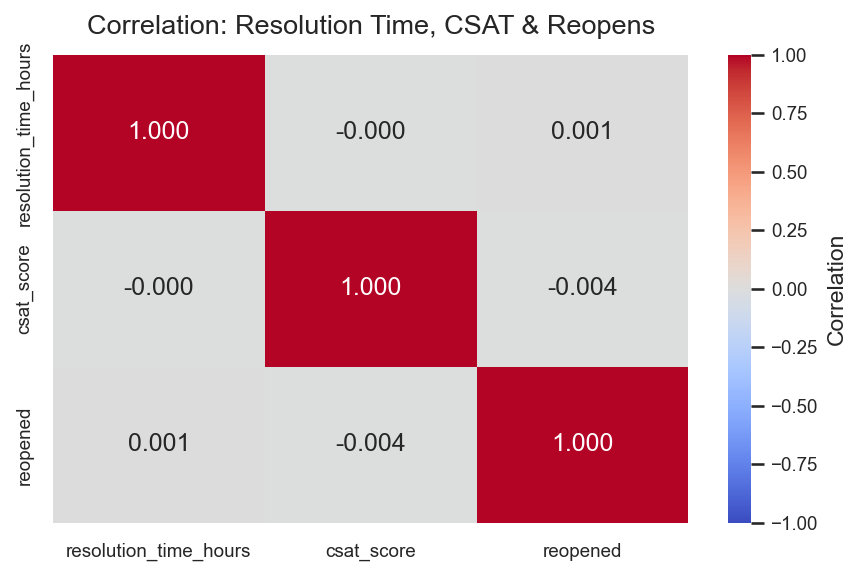

In [19]:
# Correlation: Resolution Time vs CSAT
corr_data = df[['resolution_time_hours', 'csat_score', 'reopened']].dropna()
corr_matrix = corr_data.corr()

fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='coolwarm',
            vmin=-1, vmax=1, center=0, ax=ax,
            cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation: Resolution Time, CSAT & Reopens', pad=10)
plt.tight_layout()
plt.savefig(f'{VISUALS_PATH}07_correlation_matrix.png', bbox_inches='tight')
plt.show()

---
## 7. Export — Processed Data for Power BI

In [20]:
# Drop text columns not needed for BI dashboard
cols_to_drop = ['initial_message', 'agent_first_reply', 'resolution_summary']
df_export = df.drop(columns=cols_to_drop)
df_export['year_month'] = df_export['year_month'].astype(str)

# Full cleaned dataset
df_export.to_csv(f'{PROCESSED_PATH}itsm_cleaned.csv', index=False)

# KPI tables
kpi_by_region.to_csv(f'{PROCESSED_PATH}kpi_by_region.csv', index=False)
kpi_by_priority.to_csv(f'{PROCESSED_PATH}kpi_by_priority.csv', index=False)

# Monthly trend
monthly_trend.drop(columns=['year_month']).to_csv(f'{PROCESSED_PATH}monthly_sla_trend.csv', index=False)

# Root cause
root_cause.to_csv(f'{PROCESSED_PATH}root_cause_breach.csv', index=False)

print('Exported to data/processed/:')
for f in os.listdir(PROCESSED_PATH):
    size = os.path.getsize(os.path.join(PROCESSED_PATH, f))
    print(f'   {f}  ({size/1024:.1f} KB)')

Exported to data/processed/:
   kpi_by_priority.csv  (0.2 KB)
   monthly_sla_trend.csv  (1.6 KB)
   root_cause_breach.csv  (0.8 KB)
   kpi_by_region.csv  (0.4 KB)
   itsm_cleaned.csv  (18134.8 KB)


---
## 8. Executive Summary

> This section mirrors the stakeholder reporting format used at HP Inc. — concise, action-oriented findings.

In [21]:
overall_breach_rate = df['sla_breached'].mean() * 100
worst_region = kpi_by_region.iloc[0]['region']
worst_region_rate = kpi_by_region.iloc[0]['sla_breach_rate_pct']
best_region  = kpi_by_region.iloc[-1]['region']
top_issue_breach = root_cause.sort_values('breach_count', ascending=False).iloc[0]

summary = f"""
╔══════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — OPS KPI REPORT            ║
╠══════════════════════════════════════════════════════════╣
║  Dataset     : 100,000 IT support tickets                ║
║  Period      : {df['created_at'].min().strftime('%b %Y')} – {df['created_at'].max().strftime('%b %Y')}                         ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                            ║
║  • Overall SLA breach rate    : {overall_breach_rate:.1f}%                  ║
║  • Highest breach region      : {worst_region} ({worst_region_rate}%)        ║
║  • Best performing region     : {best_region}                    ║
║  • Top breach driver          : {top_issue_breach['issue_type']} in {top_issue_breach['region']}  ║
║                                                          ║
║  RECOMMENDATIONS                                         ║
║  1. Priority triage: Critical tickets breach SLA most    ║
║     — review staffing ratios for P1/P2 queues            ║
║  2. Regional intervention: Focus on {worst_region} ops       ║
║     — root cause shows {top_issue_breach['issue_type']} as top driver    ║
║  3. SLA breach directly lowers CSAT (p<0.05) —           ║
║     quantified business case for SLA investment          ║
╚══════════════════════════════════════════════════════════╝
"""
print(summary)


╔══════════════════════════════════════════════════════════╗
║           EXECUTIVE SUMMARY — OPS KPI REPORT            ║
╠══════════════════════════════════════════════════════════╣
║  Dataset     : 100,000 IT support tickets                ║
║  Period      : Jan 2022 – Dec 2025                         ║
╠══════════════════════════════════════════════════════════╣
║  KEY FINDINGS                                            ║
║  • Overall SLA breach rate    : 24.9%                  ║
║  • Highest breach region      : APAC (25.98%)        ║
║  • Best performing region     : Unknown                    ║
║  • Top breach driver          : billing_problem in APAC  ║
║                                                          ║
║  RECOMMENDATIONS                                         ║
║  1. Priority triage: Critical tickets breach SLA most    ║
║     — review staffing ratios for P1/P2 queues            ║
║  2. Regional intervention: Focus on APAC ops       ║
║     — root cause shows billing

---
*Built by Saran Chandrasekharan Unnithan Rani | [LinkedIn](https://www.linkedin.com/in/sarancur/) | [GitHub](https://github.com/sarancur)*